In [ ]:
import seaborn as sns, pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# 1. Setup and Persistence Configuration
MODEL_PATH = 'model_persistence/human_activity_full_package.pkl'

# Load data and initial LabelEncoding
data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv")

# 2. Training/Loading Logic
if os.path.exists(MODEL_PATH):
    print("Loading models and encoder from storage...")
    storage = joblib.load(MODEL_PATH)
    le = storage['le']
    lr = storage['lr']
    lr_l1 = storage['l1']
    lr_l2 = storage['l2']
    data['Activity'] = le.transform(data['Activity'])
else:
    print("Training models... (Grab a coffee, this will take time)")
    le = LabelEncoder()
    data['Activity'] = le.fit_transform(data['Activity'])
    
    # Define Split
    feature_cols = data.columns[:-1]
    strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
    X_train, y_train = data.loc[train_idx, feature_cols], data.loc[train_idx, 'Activity']

    # Helper: Bundle Scaler + Model into a Pipeline
    def make_pipe(model_obj):
        return Pipeline([('scaler', StandardScaler()), ('model', model_obj)])

    # Fit Pipelines
    lr = make_pipe(LogisticRegression(solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l1 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(1,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l2 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(0,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)

    # Save to one file
    joblib.dump({'lr': lr, 'l1': lr_l1, 'l2': lr_l2, 'le': le}, MODEL_PATH)

# 3. Predict & Generate Metrics (Always runs)
feature_cols = data.columns[:-1]
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
X_test, y_test = data.loc[test_idx, feature_cols], data.loc[test_idx, 'Activity']

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

y_pred = pd.concat([pd.Series(m.predict(X_test), name=l) for l, m in zip(coeff_labels, coeff_models)], axis=1)

# 4. Calculation & Confusion Matrices
metrics = []
cm = {}

for lab in coeff_labels:
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')
    accuracy = accuracy_score(y_test, y_pred[lab])
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
                        label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), average='weighted')
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 'fscore':fscore, 'accuracy':accuracy, 'auc':auc}, name=lab))

# Final Display
print(pd.concat(metrics, axis=1))

# 5. Plotting
fig, axList = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axList = axList.flatten()
axList[-1].axis('off')

for ax, lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d', cmap='Blues')
    ax.set(title=f'Model: {lab}', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos


food_df = pd.read_csv("data/food_items.csv")

X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)



# Elastic Net
cven_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[0.86,0.87,0.88], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cven_preds = cven_model.predict(X_test)

print("Elastic-Net model metrices:")
display(evaluate_metrics(y_test, cven_preds))
print(f"cven_model.C (steepness): {cven_model.named_steps['model'].C_}")
print(f"cven_model.l1_ratio: {cven_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cven_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cven_model.classes_)
disp.plot()
plt.title('Elastic Net (' + str(cven_model.named_steps['model'].l1_ratio_) + ')')
plt.show()




# L1 model
cvl1_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[1.0], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cvl1_preds = cvl1_model.predict(X_test)

print("L1 model metrices:")
display(evaluate_metrics(y_test, cvl1_preds))
print(f"cvl1_model.C (steepness): {cvl1_model.named_steps['model'].C_}")
print(f"cvl1_model.l1_ratio: {cvl1_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cvl1_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cvl1_model.classes_)
disp.plot()
plt.title('L1 Lasso (' + str(cvl1_model.named_steps['model'].l1_ratio_) + ')')
plt.show()




# L2 model
cvl2_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[0.0], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cvl2_preds = cvl2_model.predict(X_test)

print("L2 model metrices:")
display(evaluate_metrics(y_test, cvl2_preds))
print(f"cvl2_model.C (steepness): {cvl2_model.named_steps['model'].C_}")
print(f"cvl2_model.l1_ratio: {cvl2_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cvl2_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cvl2_model.classes_)
disp.plot()
plt.title('L2 Ridge (' + str(cvl2_model.named_steps['model'].l1_ratio_) + ')')
plt.show()


L1 model metrices (CV model via Pipeline):


{'accuracy': 0.8174962292609351,
 'recall': array([0.86766917, 0.74466192, 0.89393939]),
 'precision': array([0.79258242, 0.84888438, 0.84285714]),
 'f1score': array([0.82842785, 0.79336493, 0.86764706])}

cvl1_model.C (steepness): 1291.5496650148827
cvl1_model.l1_ratio: 1.0


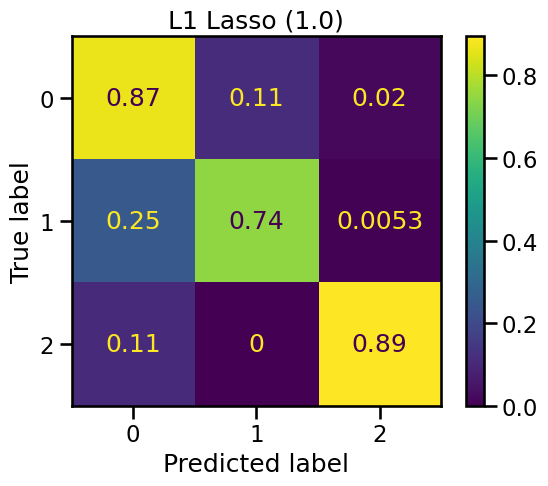

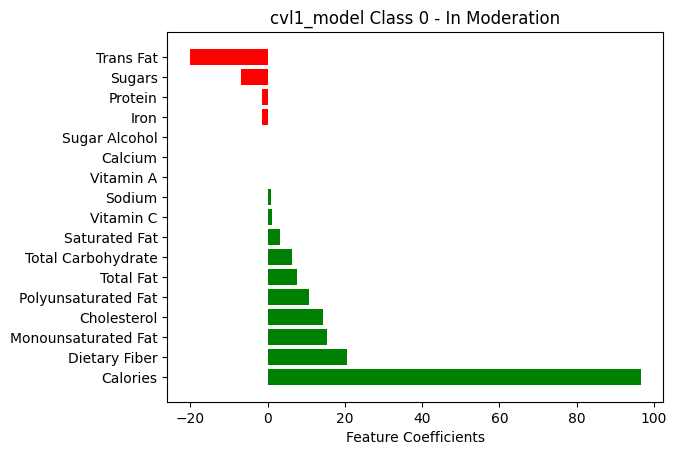

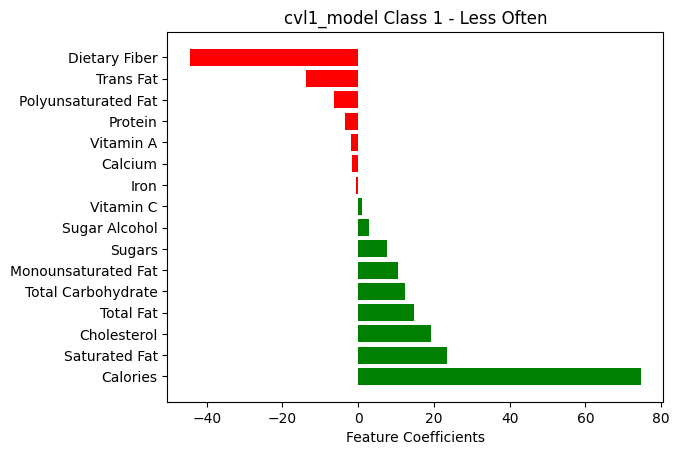

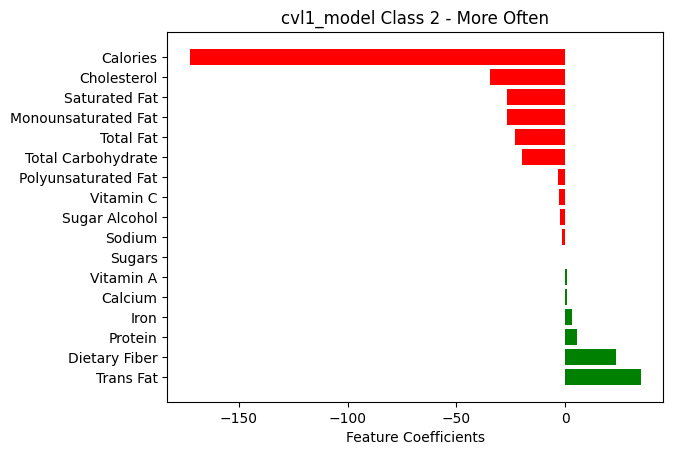

In [3]:
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict,title=''):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.set_xlabel('Feature Coefficients')
    ax.set_title(title)
    plt.show()



food_df = pd.read_csv("data/food_items.csv")

X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]
feature_cols = list(food_df.iloc[:, :-1].columns)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)


# L1 model
cvl1_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=[1291.5496650148827], cv=None, l1_ratios=[1.0], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cvl1_preds = cvl1_model.predict(X_test)

print("L1 model metrices (CV model via Pipeline):")
display(evaluate_metrics(y_test, cvl1_preds))
print(f"cvl1_model.C (steepness): {cvl1_model.named_steps['model'].C_}")
print(f"cvl1_model.l1_ratio: {cvl1_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cvl1_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cvl1_model.classes_)
disp.plot()
plt.title('L1 Lasso (' + str(cvl1_model.named_steps['model'].l1_ratio_) + ')')
plt.show()

# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 0, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 0 - In Moderation')

# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 1, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 1 - Less Often')

# Coefficients for Class 2, More Often
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 2, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 2 - More Often')


Non CV outputs:

L1 model metrices:


{'accuracy': 0.8174962292609351,
 'recall': array([0.86766917, 0.74466192, 0.89393939]),
 'precision': array([0.79258242, 0.84888438, 0.84285714]),
 'f1score': array([0.82842785, 0.79336493, 0.86764706])}

l1_model.C (steepness): 1291.5496650148827
l1_model.l1_ratio: 1.0


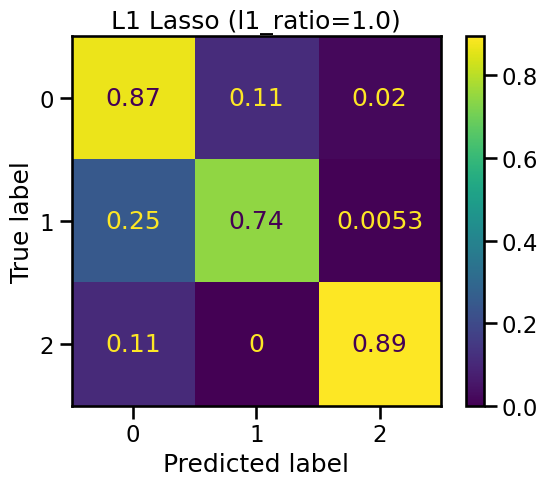

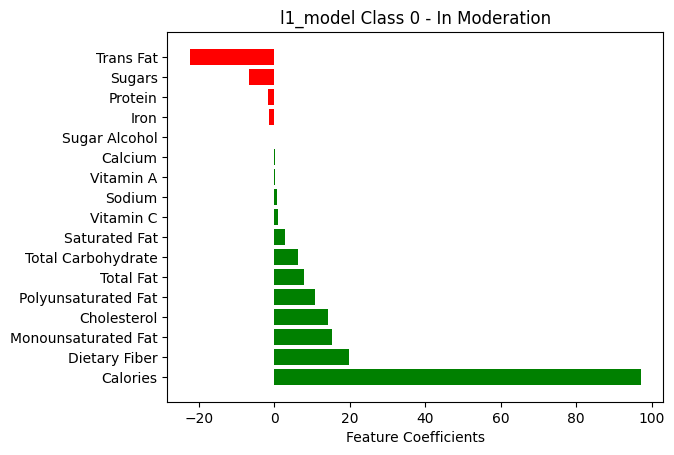

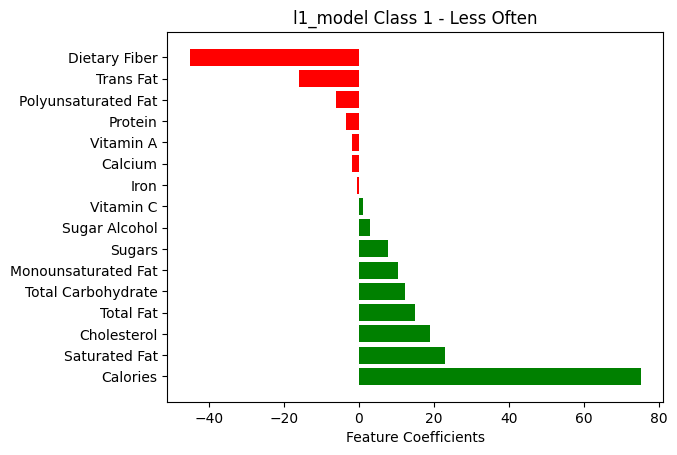

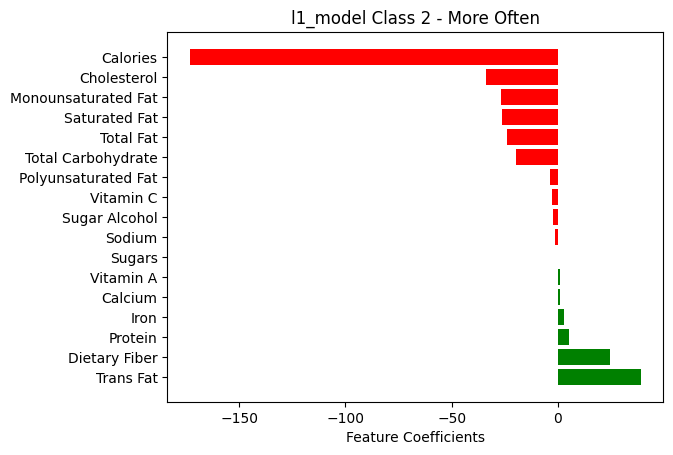

In [2]:
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict,title=''):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.set_xlabel('Feature Coefficients')
    ax.set_title(title)
    plt.show()



food_df = pd.read_csv("data/food_items.csv")

X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]
feature_cols = list(food_df.iloc[:, :-1].columns)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



l1_model = LogisticRegression(
                C=1291.5496650148827,
                random_state=42, 
                l1_ratio=1.0,       # 1.0 means 100% L1 (Lasso); 0.0 means 100% L2 (Ridge); l1_ratio is for Elastic Net
                solver='saga',      # for L1 (Lasso) model, only 'saga' or 'liblinear' support L1
                max_iter=5000
            )

l1_model.fit(X_train_scaled, y_train)
l1_preds = l1_model.predict(X_test_scaled)

print("L1 model metrices:")
display(evaluate_metrics(y_test, l1_preds))
print(f"l1_model.C (steepness): {l1_model.C}")
print(f"l1_model.l1_ratio: {l1_model.l1_ratio}")

cf = confusion_matrix(y_test, l1_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=l1_model.classes_)
disp.plot()
plt.title('L1 Lasso (l1_ratio=1.0)')
plt.show()


# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(l1_model, 0, feature_cols)
visualize_coefs(coef_dict, 'l1_model Class 0 - In Moderation')

# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(l1_model, 1, feature_cols)
visualize_coefs(coef_dict, 'l1_model Class 1 - Less Often')

# Coefficients for Class 2, More Often
coef_dict = get_feature_coefs(l1_model, 2, feature_cols)
visualize_coefs(coef_dict, 'l1_model Class 2 - More Often')